<a href="https://colab.research.google.com/github/Venisriyallampalli/ML/blob/main/FL_for_energy_consumption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Federated Learning for Energy Consumption Prediction in Smart Homes

In [ ]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip

--2026-04-06 09:48:04--  https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘household_power_consumption.zip.5’

household_power_con     [       <=>          ]  19.68M  12.1MB/s    in 1.6s    

2026-04-06 09:48:07 (12.1 MB/s) - ‘household_power_consumption.zip.5’ saved [20640916]



This code downloads the `household_power_consumption.zip` dataset from the UCI Machine Learning Repository, which contains household power consumption data.

In [ ]:
!unzip household_power_consumption.zip

Archive:  household_power_consumption.zip
replace household_power_consumption.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: household_power_consumption.txt  


This cell unzips the downloaded archive, extracting the `household_power_consumption.txt` file containing the raw data.

In [ ]:
!pip install flwr[simulation] pandas numpy scikit-learn matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

import flwr as fl

This cell installs necessary Python libraries like `flwr`, `pandas`, `numpy`, `scikit-learn`, and `matplotlib`, and then imports them for use in the notebook. These libraries are essential for data manipulation, machine learning, and federated learning.

In [ ]:
# Load dataset
data = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    low_memory=False,
    na_values="?"
)

# Drop missing values
data = data.dropna()

# Convert numeric columns
cols = [
    "Global_active_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in cols:
    data[col] = data[col].astype(float)

# Create datetime feature
data["datetime"] = pd.to_datetime(data["Date"] + " " + data["Time"])
data["hour"] = data["datetime"].dt.hour

# Select features
features = ["Voltage", "Global_intensity", "Sub_metering_1", "hour"]
target = "Global_active_power"

X = data[features]
y = data[target]

# Normalize
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Reduce dataset size (for faster Colab execution)
X = X[:50000]
y = y[:50000]

/tmp/ipykernel_22599/1528452130.py:26: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data["datetime"] = pd.to_datetime(data["Date"] + " " + data["Time"])


In [ ]:
data.head(50)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,datetime,hour
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,17
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,17
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,17
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,17
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,17
5,16/12/2006,17:29:00,3.520,0.522,235.02,15.0,0.0,2.0,17.0,2006-12-16 17:29:00,17
6,16/12/2006,17:30:00,3.702,0.520,235.09,15.8,0.0,1.0,17.0,2006-12-16 17:30:00,17
7,16/12/2006,17:31:00,3.700,0.520,235.22,15.8,0.0,1.0,17.0,2006-12-16 17:31:00,17
8,16/12/2006,17:32:00,3.668,0.510,233.99,15.8,0.0,1.0,17.0,2006-12-16 17:32:00,17
9,16/12/2006,17:33:00,3.662,0.510,233.86,15.8,0.0,2.0,16.0,2006-12-16 17:33:00,17


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


This cell loads and preprocesses the dataset. It reads the CSV, handles missing values, converts relevant columns to numeric types, creates a datetime feature, selects specific features and a target variable, and normalizes the feature data. Finally, it reduces the dataset size to 50,000 entries to speed up execution in Colab.

In [ ]:
# Split into 4 clients (simulate 4 homes)
num_clients = 4
client_data = []

split_size = len(X) // num_clients

for i in range(num_clients):
    start = i * split_size
    end = (i + 1) * split_size

    X_client = X[start:end]
    y_client = y[start:end]

    X_train, X_test, y_train, y_test = train_test_split(
        X_client, y_client, test_size=0.2, random_state=42
    )

    client_data.append((X_train, X_test, y_train, y_test))

This cell splits the preprocessed dataset into four parts, simulating data belonging to four different clients (e.g., smart homes). Each client's data is further split into training and testing sets, which is crucial for simulating a federated learning environment.

In [ ]:
def get_model():
    return LinearRegression()

This simple function defines and returns a `LinearRegression` model from `scikit-learn`. This model will be used as the base model for the federated learning setup.

In [ ]:
class EnergyClient(fl.client.NumPyClient):
    def __init__(self, X_train, X_test, y_train, y_test):
        self.model = LinearRegression()
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test

        # ✅ IMPORTANT FIX: Initialize model
        self.model.fit(self.X_train[:10], self.y_train[:10])
#client->server
    def get_parameters(self, config):
        return [
            self.model.coef_,
            np.array([self.model.intercept_])
        ]
#server->client
    def set_parameters(self, parameters):
        self.model.coef_ = parameters[0]
        self.model.intercept_ = parameters[1][0]

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        self.model.fit(self.X_train, self.y_train)
        return self.get_parameters(config), len(self.X_train), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        preds = self.model.predict(self.X_test)
        loss = mean_absolute_error(self.y_test, preds)
        return loss, len(self.X_test), {"mae": loss}

This cell defines the `EnergyClient` class, which inherits from `fl.client.NumPyClient`. This class implements the client-side logic for federated learning, including methods to get and set model parameters, fit the model on local data, and evaluate its performance.

In [ ]:
!pip install -U "flwr[simulation]"
!pip install ray
def client_fn(cid):
    X_train, X_test, y_train, y_test = client_data[int(cid)]
    return EnergyClient(X_train, X_test, y_train, y_test)

strategy = fl.server.strategy.FedAvg()

fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=4,
    config=fl.server.ServerConfig(num_rounds=5),
    strategy=strategy,
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

          

History (loss, distributed):
	round 1: 0.04187618490231946
	round 2: 0.04187618490231946
	round 3: 0.04187618490231946
	round 4: 0.04187618490231946
	round 5: 0.04187618490231946

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


This cell sets up and starts the federated learning simulation. It defines a `client_fn` to create clients, initializes a `FedAvg` strategy, and runs the simulation for 5 rounds using the `LinearRegression` model.

In [ ]:
# Train a centralized model for comparison
model = LinearRegression()
model.fit(X, y)

preds = model.predict(X)

mae = mean_absolute_error(y, preds)
print("Centralized Model MAE:", mae)

Centralized Model MAE: 0.04194153663479428


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


This cell trains a single, centralized `LinearRegression` model on the entire dataset for comparison. It then calculates and prints the Mean Absolute Error (MAE) for this centralized model to serve as a baseline.

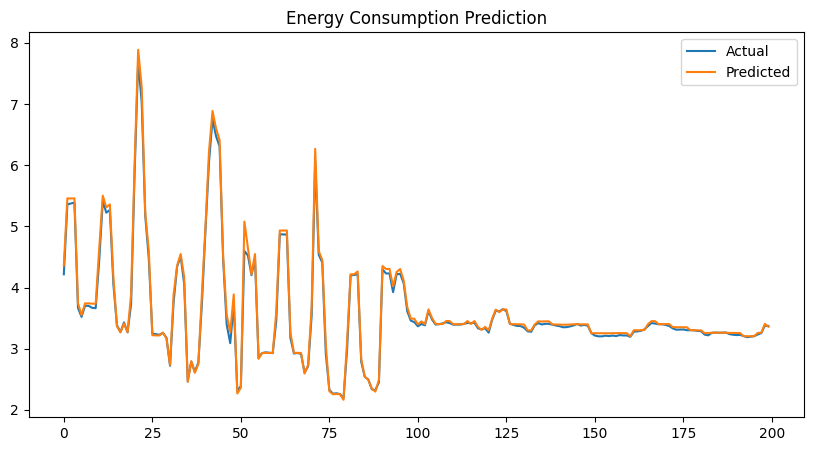

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y[:200], label="Actual")
plt.plot(preds[:200], label="Predicted")
plt.legend()
plt.title("Energy Consumption Prediction")
plt.show()

This cell visualizes the predictions of the centralized linear regression model against the actual values for the first 200 data points. This plot helps in understanding the model's performance graphically.

 USING LSTM

This text cell indicates a new section focusing on improving the model using Long Short-Term Memory (LSTM) networks.

In [ ]:
# STEP 1: Convert data into sequences for LSTM
y_array = y.values

def create_sequences(X, y, time_steps=10):
    X_seq = []
    y_seq = []

    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])

    return np.array(X_seq), np.array(y_seq)


TIME_STEPS = 10

X_seq, y_seq = create_sequences(X, y_array, TIME_STEPS)

print("Sequence shape:", X_seq.shape)
print("Target shape:", y_seq.shape)

Sequence shape: (49990, 10, 4)
Target shape: (49990,)


This cell prepares the data for LSTM by converting it into sequences. The `create_sequences` function transforms the features (`X`) and target (`y`) into a format suitable for time-series prediction, where each sample includes a sequence of past observations.

In [ ]:
# STEP 2: Split sequence data into clients

num_clients = 4
client_data = []

split_size = len(X_seq) // num_clients

for i in range(num_clients):
    start = i * split_size
    end = (i + 1) * split_size

    X_client = X_seq[start:end]
    y_client = y_seq[start:end]

    # Train-test split for each client
    split = int(0.8 * len(X_client))

    X_train = X_client[:split]
    X_test = X_client[split:]

    y_train = y_client[:split]
    y_test = y_client[split:]

    client_data.append((X_train, X_test, y_train, y_test))

print("Client 1 train shape:", client_data[0][0].shape)

Client 1 train shape: (9997, 10, 4)


Similar to the linear regression setup, this cell splits the LSTM-ready sequence data among four simulated clients. Each client receives a portion of the data, which is then further divided into training and testing sets.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

print("TensorFlow working ✅")

TensorFlow working ✅


This cell imports necessary components from TensorFlow's Keras API for building neural networks, specifically `Sequential`, `LSTM`, and `Dense` layers. It also confirms that TensorFlow is working correctly.

In [ ]:
# STEP 3: Define LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

def get_lstm_model(input_shape):
    model = Sequential()

    model.add(LSTM(50, return_sequences=False, input_shape=input_shape))
    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=['mae']
    )

    return model


# Test model creation
input_shape = (X_seq.shape[1], X_seq.shape[2])  # (timesteps, features)
model = get_lstm_model(input_shape)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,051 (43.17 KB)

 Trainable params: 11,051 (43.17 KB)

 Non-trainable params: 0 (0.00 B)

This cell defines the `get_lstm_model` function, which creates a simple LSTM neural network. The model consists of an LSTM layer and a dense output layer, compiled with the Adam optimizer and Mean Squared Error loss. It then displays a summary of the model's architecture.

In [ ]:
# STEP 4: LSTM-based Flower Client

class LSTMClient(fl.client.NumPyClient):
    def __init__(self, X_train, X_test, y_train, y_test):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test

        self.model = get_lstm_model((X_train.shape[1], X_train.shape[2]))

    def get_parameters(self, config):
        return self.model.get_weights()

    def set_parameters(self, parameters):
        self.model.set_weights(parameters)

    def fit(self, parameters, config):
        self.set_parameters(parameters)

        self.model.fit(
            self.X_train, self.y_train,
            epochs=1,              # keep small for FL rounds
            batch_size=32,
            verbose=0
        )

        return self.model.get_weights(), len(self.X_train), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)

        loss, mae = self.model.evaluate(self.X_test, self.y_test, verbose=0)

        return loss, len(self.X_test), {"mae": mae}

This cell defines the `LSTMClient` class, which is a specialized client for federated learning using an LSTM model. It extends `fl.client.NumPyClient` and includes methods to manage model parameters, train the LSTM model locally, and evaluate its performance.

In [ ]:
def client_fn(cid):
    X_train, X_test, y_train, y_test = client_data[int(cid)]
    return LSTMClient(X_train, X_test, y_train, y_test)

This function `client_fn` is responsible for creating and returning an `LSTMClient` instance for a given client ID. It uses the pre-split client data to initialize each client's local dataset.

In [ ]:
strategy = fl.server.strategy.FedAvg()

fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=4,
    config=fl.server.ServerConfig(num_rounds=5),
    strategy=strategy,
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2026-04-06 09:49:41,583	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'memory': 9224613888.0, 'node:172.28.0.12': 1.0, 'object_st

History (loss, distributed):
	round 1: 0.36039068549871445
	round 2: 0.2923474330455065
	round 3: 0.27293254621326923
	round 4: 0.2583944555372
	round 5: 0.24311124067753553

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


This cell initiates a new federated learning simulation, this time using the LSTM model clients. It employs the `FedAvg` strategy and runs for 5 rounds to collaboratively train the LSTM model across the clients.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.0034 - mae: 0.0343 - val_loss: 0.0033 - val_mae: 0.0303
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.0022 - mae: 0.0262 - val_loss: 0.0027 - val_mae: 0.0294
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - loss: 0.0020 - mae: 0.0245 - val_loss: 0.0026 - val_mae: 0.0256
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - loss: 0.0020 - mae: 0.0238 - val_loss: 0.0025 - val_mae: 0.0291
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.0019 - mae: 0.0232 - val_loss: 0.0024 - val_mae: 0.0256
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.0019 - mae: 0.0230 - val_loss: 0.0024 - val_mae: 0.0257
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.0018 - mae: 0.0228 - val_loss: 0.0026 - val_mae: 0.0304
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0018 - mae: 0.0226 - val_loss: 0.0023 - val_mae: 0.0268
Epoch 9/10
1250/1250 ━━━━━

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


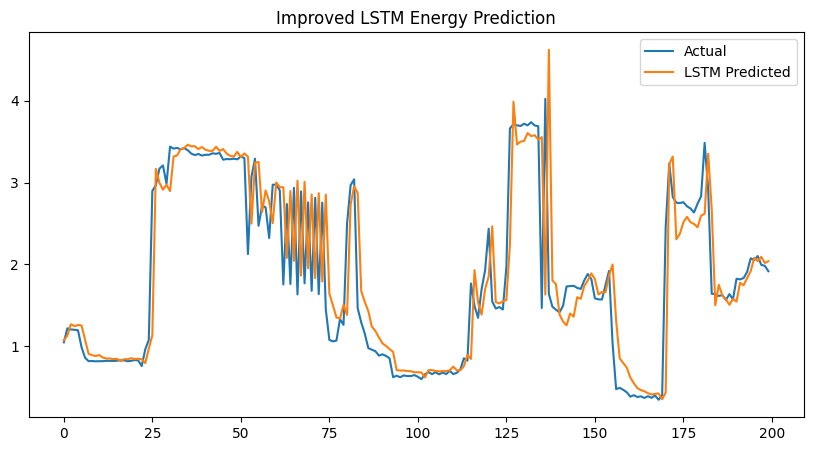

In [ ]:
# ✅ STEP 6: IMPROVED LSTM (CORRECT PIPELINE)

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential

# ----------------------------
# 1. SCALE TARGET (IMPORTANT)
# ----------------------------
y_scaler = MinMaxScaler()
y_scaled = y_scaler.fit_transform(y.values.reshape(-1,1))

# ----------------------------
# 2. RECREATE SEQUENCES
# ----------------------------
def create_sequences(X, y, time_steps=10):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i+time_steps])
        y_seq.append(y[i+time_steps])
    return np.array(X_seq), np.array(y_seq)

TIME_STEPS = 10
X_seq, y_seq = create_sequences(X, y_scaled, TIME_STEPS)

# ----------------------------
# 3. TRAIN-TEST SPLIT
# ----------------------------
split = int(0.8 * len(X_seq))

X_train = X_seq[:split]
X_test = X_seq[split:]

y_train = y_seq[:split]
y_test = y_seq[split:]

# ----------------------------
# 4. IMPROVED LSTM MODEL
# ----------------------------
def get_better_lstm(input_shape):
    model = Sequential()

    model.add(LSTM(64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))

    model.add(LSTM(32))
    model.add(Dense(1))

    model.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=['mae']
    )

    return model

model = get_better_lstm((X_seq.shape[1], X_seq.shape[2]))

# ----------------------------
# 5. TRAIN MODEL (IMPORTANT)
# ----------------------------
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# ----------------------------
# 6. PREDICT
# ----------------------------
preds = model.predict(X_test)

# ----------------------------
# 7. INVERSE SCALING
# ----------------------------
preds_actual = y_scaler.inverse_transform(preds)
y_actual = y_scaler.inverse_transform(y_test)

# ----------------------------
# 8. MAE
# ----------------------------
mae_lstm = mean_absolute_error(y_actual, preds_actual)

print("LSTM MAE:", mae_lstm)

# ----------------------------
# 9. VISUALIZATION
# ----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_actual[:200], label="Actual")
plt.plot(preds_actual[:200], label="LSTM Predicted")
plt.legend()
plt.title("LSTM Energy Prediction")
plt.show()

This cell introduces an improved LSTM model pipeline. It correctly scales the target variable (`y`), recreates sequences, performs a train-test split, defines a more complex LSTM model with Dropout layers, trains the model, makes predictions, and then inverse-scales the predictions and actual values to calculate and display the MAE. Finally, it visualizes the improved LSTM's predictions.

In [ ]:
from sklearn.metrics import mean_absolute_error

# ----------------------------
# OLD MODEL (Linear Regression)
# ----------------------------
old_model = LinearRegression()
old_model.fit(X, y)

preds_old = old_model.predict(X)

# Align with sequence length
preds_old_seq = preds_old[TIME_STEPS:]
y_old_seq = y.values[TIME_STEPS:]

mae_old = mean_absolute_error(y_old_seq, preds_old_seq)

print("✅ Old Model (Linear Regression) MAE:", mae_old)


# ----------------------------
# LSTM MODEL (Correct Scale)
# ----------------------------
# preds_actual and y_actual already inverse scaled in STEP 6

mae_lstm = mean_absolute_error(y_actual, preds_actual)

print("✅ Improved LSTM MAE:", mae_lstm)

✅ Old Model (Linear Regression) MAE: 0.04193551422981804
✅ Improved LSTM MAE: 0.21944910376045462


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


This cell compares the performance of the old `LinearRegression` model with the improved LSTM model. It calculates the MAE for the linear regression model on a sequence-aligned dataset and then reiterates the MAE for the improved LSTM model, highlighting the performance difference.